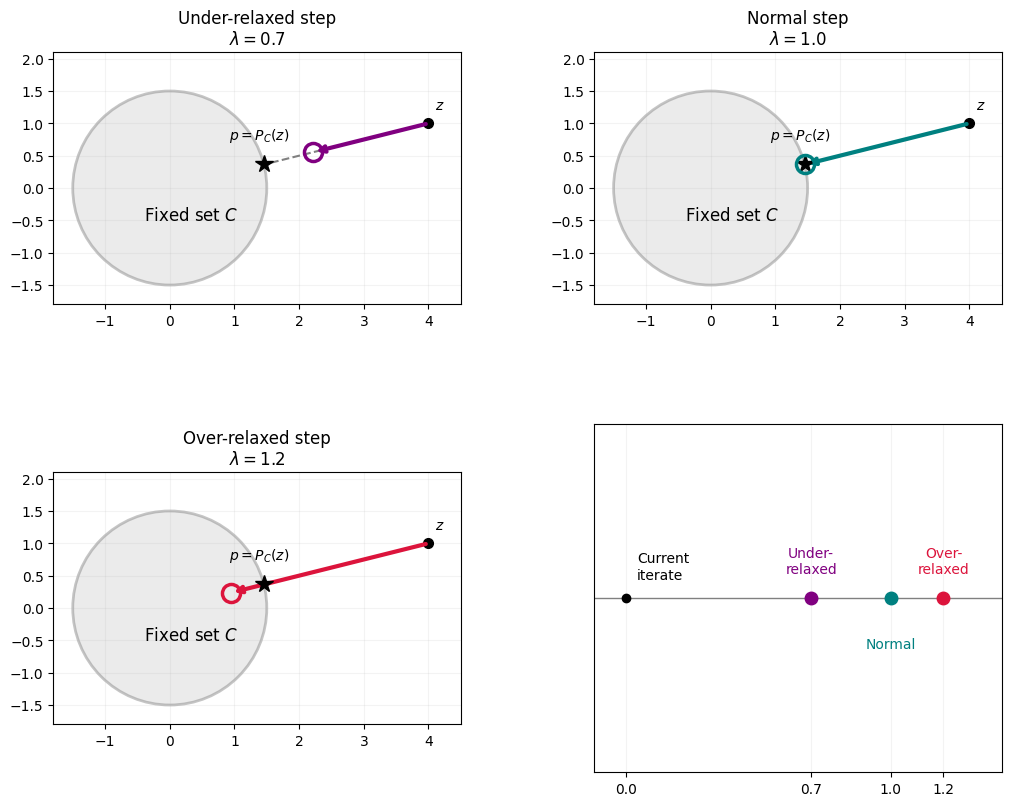

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Fixed set
center = np.array([0.0, 0.0])
radius = 1.5
z = np.array([4.0, 1.0])


direction = z - center
p = center + radius / np.linalg.norm(direction) * direction
d = p - z

cases = [
    ("Under-relaxed step", 0.7, "purple"),
    ("Normal step", 1.0, "teal"),
    ("Over-relaxed step", 1.2, "crimson"),
]

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
grid = fig.add_gridspec(
    2, 2,
    height_ratios=[3, 3],
    wspace=0.18,
    hspace=0.18
)

positions = [(0, 0), (0, 1), (1, 0)]

# Main panels
for (name, lam, color), pos in zip(cases, positions):
    ax = fig.add_subplot(grid[pos])

    new = z + lam * d

    ax.add_patch(
        Circle(
            center,
            radius,
            facecolor="lightgray",
            edgecolor="gray",
            alpha=0.45,
            linewidth=2
        )
    )

    ax.text(-0.4, -0.5, r"Fixed set $C$", fontsize=12)

    ax.plot(
        [z[0], p[0]],
        [z[1], p[1]],
        "--",
        color="gray"
    )

    ax.annotate(
        "",
        xy=new,
        xytext=z,
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=3
        )
    )

    ax.plot(*z, "ko", ms=7)
    ax.plot(*p, "k*", ms=13, zorder=5)

    ax.plot(
        *new,
        "o",
        mfc="none",
        mec=color,
        mew=2.5,
        ms=13,
        zorder=6
    )

    ax.annotate(
        r"$z$",
        z,
        xytext=(5, 10),
        textcoords="offset points"
    )

    ax.annotate(
        r"$p=P_C(z)$",
        p,
        xytext=(-25, 18),
        textcoords="offset points"
    )

    ax.set_title(
        f"{name}\n" + rf"$\lambda={lam}$",
        fontsize=12
    )

    ax.set_xlim(-1.8, 4.5)
    ax.set_ylim(-1.8, 2.1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)


# Bottom-right panel
ax = fig.add_subplot(grid[1, 1])

ax.axhline(0, color="gray", lw=1)
ax.plot(0, 0, "ko")

ax.annotate(
    "Current\niterate",
    (0, 0),
    xytext=(8, 12),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=10
)

for name, lam, color in cases:
    ax.plot(lam, 0, "o", color=color, ms=9)

    if lam == 1.0:
        label = "Normal"
        offset = -28
    elif lam > 1.0:
        label = "Over-\nrelaxed"
        offset = 16
    else:
        label = "Under-\nrelaxed"
        offset = 16

    ax.annotate(
        label,
        (lam, 0),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="bottom" if offset > 0 else "top",
        color=color,
        fontsize=10
    )

ax.set_xlim(-0.12, 1.42)
ax.set_ylim(-0.32, 0.32)

ax.set_yticks([])
ax.set_xticks([0, 0.7, 1.0, 1.2])

ax.set_xlabel(
    r"",
    fontsize=11
)

ax.grid(alpha=0.15)

plt.savefig(
    "relaxation_steps.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "relaxation_steps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


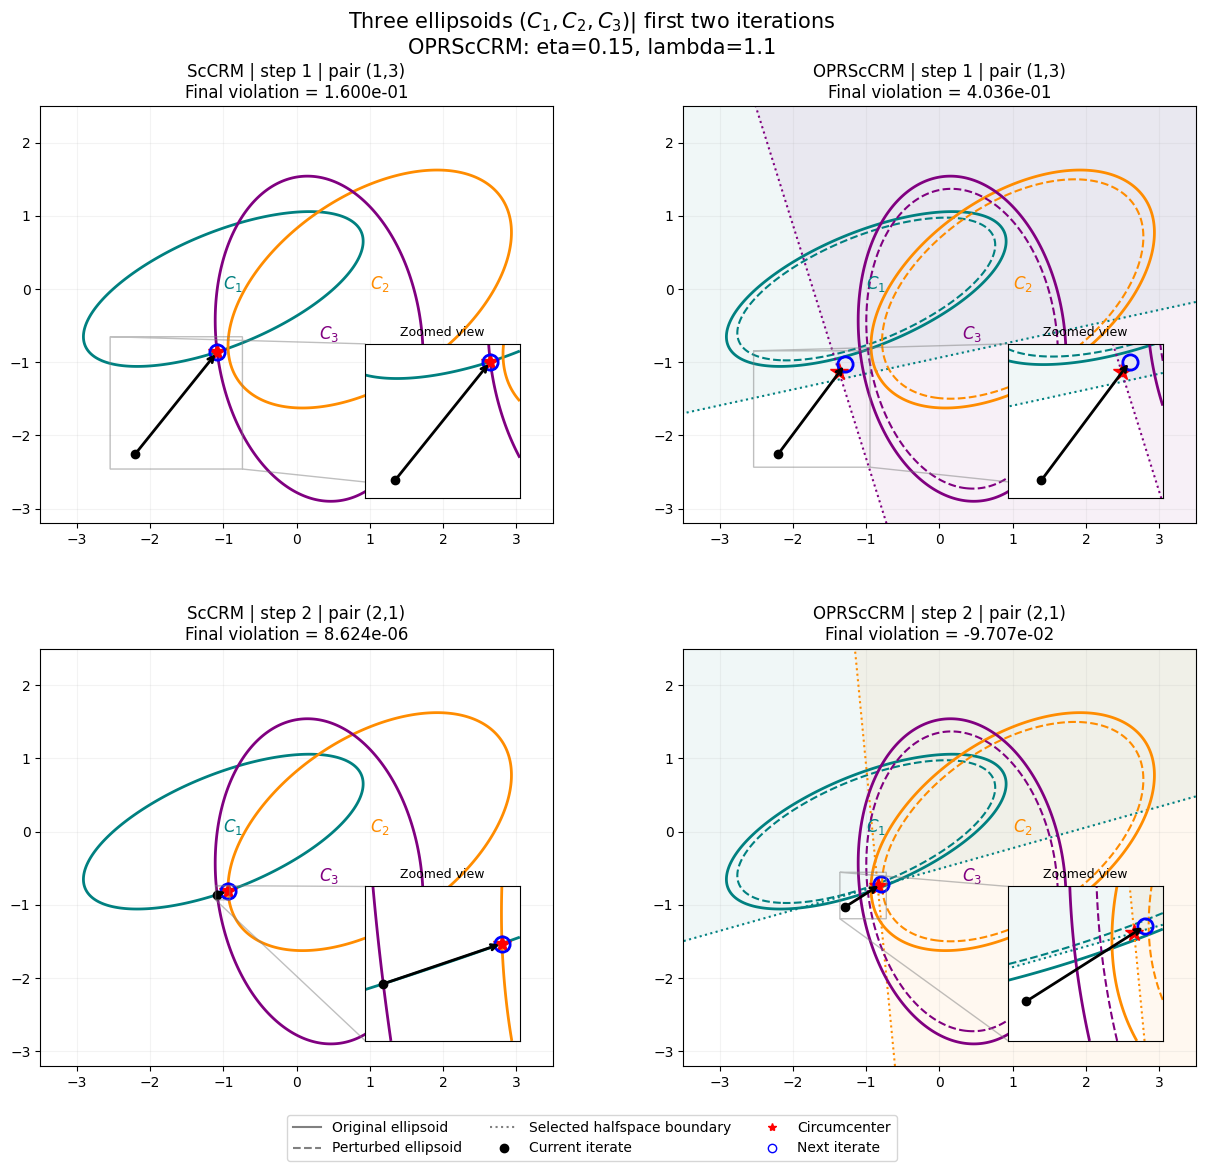

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.lines import Line2D

Y = np.array([
    [-1., 0.],
    [1., 0.],
    [.30862043, -.67881346]
])

Q = np.array([
    [[.442, -.4922], [-.4922, 1.443]],
    [[.3448, -.195], [-.195, .4891]],
    [[.50295466, .03606170], [.03606170, .20547448]]
])

Z0 = np.array([-2.2, -2.25])

ETA, LAMBDA, TOL = .15, 1.1, 1e-8


def f(x, i):
    d = x - Y[i]
    return np.einsum("...i,ij,...j->...", d, Q[i], d) - 1


def exact(x, i):
    if f(x, i) <= 1e-12:
        return x.copy()

    e, U = np.linalg.eigh(Q[i])
    d = U.T @ (x - Y[i])

    equation = lambda t: np.sum(e * (d / (1 + t * e))**2) - 1

    hi = 1.
    while equation(hi) > 0:
        hi *= 2

    return Y[i] + U @ (d / (1 + brentq(equation, 0, hi) * e))


def step(z, perturbed):
    def P(x, i):
        if not perturbed:
            return exact(x, i)

        a = 2 * Q[i] @ (z - Y[i])
        b = f(z, i) + ETA

        if b <= 0:
            return x.copy()

        if a @ a <= 1e-20:
            raise ValueError("Invalid halfspace normal")

        return x - max(0., b + a @ (x - z)) / (a @ a) * a

    ell = int(np.argmax([f(z, i) for i in range(3)]))
    a = P(z, ell)

    r = max(
        (i for i in range(3) if i != ell),
        key=lambda i: f(a, i)
    )

    b = P(a, r)
    u = (b + P(b, ell)) / 2

    D = np.array([
        2 * (P(u, ell) - u),
        2 * (P(u, r) - u)
    ])

    rhs = np.sum(D * D, axis=1) / 2
    h = np.linalg.lstsq(D, rhs, rcond=None)[0]

    assert np.linalg.norm(D @ h - rhs) < 1e-9, "Undefined circumcenter"

    c = u + h

    return z + (LAMBDA if perturbed else 1) * (c - z), c, (ell, r)


colors = ["teal", "darkorange", "purple"]

X, V = np.meshgrid(
    np.linspace(-3.5, 3.5, 500),
    np.linspace(-3.2, 2.5, 500)
)

G = np.stack([X, V], axis=-1)


def draw(ax, z, new, c, pair, perturbed, limits=None, labels=True):
    if limits is None:

        limits = (-3.5, 3.5, -3.2, 2.5)
        Xp, Vp, Gp = X, V, G
    else:

        Xp, Vp = np.meshgrid(
            np.linspace(limits[0], limits[1], 500),
            np.linspace(limits[2], limits[3], 500)
        )

        Gp = np.stack([Xp, Vp], axis=-1)

    def contour(values, level, **kwargs):

        if np.min(values) < level < np.max(values):
            ax.contour(
                Xp, Vp, values,
                levels=[level],
                **kwargs
            )

    for i, color in enumerate(colors):
        values = f(Gp, i)

        contour(values, 0, colors=[color], linewidths=2)

        if labels:
            ax.text(
                *Y[i],
                rf"$C_{{{i+1}}}$",
                color=color,
                fontsize=12
            )

        if perturbed:
            contour(
                values, -ETA,
                colors=[color],
                linestyles="--"
            )

            if i in pair and f(z, i) + ETA > 0:
                a = 2 * Q[i] @ (z - Y[i])
                H = f(z, i) + (Gp - z) @ a + ETA

                contour(
                    H, 0,
                    colors=[color],
                    linestyles=":"
                )

                ax.contourf(
                    Xp, Vp, H,
                    levels=[-1e6, 0],
                    colors=[color],
                    alpha=.06
                )

    ax.plot(*z, "ko")

    if new is not None:
        ax.annotate(
            "",
            xy=new,
            xytext=z,
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=2
            )
        )

        ax.plot(*c, "r*", ms=13)

        ax.plot(
            *new, "o",
            mfc="none",
            mec="blue",
            ms=11,
            mew=2
        )

    ax.set(
        xlim=limits[:2],
        ylim=limits[2:],
        aspect="equal"
    )

    ax.grid(alpha=.15)


def add_zoom(ax, z, new, c, pair, perturbed):
    points = np.vstack([
        p for p in (z, new, c)
        if p is not None
    ])

    lower = points.min(axis=0)
    upper = points.max(axis=0)

    middle = (lower + upper) / 2

    size = max(.65 * np.max(upper - lower), .002)

    limits = (
        middle[0] - size,
        middle[0] + size,
        middle[1] - size,
        middle[1] + size
    )


    inset = ax.inset_axes(
        [.60, .06, .37, .37],
        zorder=10
    )

    draw(
        inset, z, new, c, pair, perturbed,
        limits=limits,
        labels=False
    )

    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title("Zoomed view", fontsize=9)

    ax.indicate_inset_zoom(
        inset,
        edgecolor="gray",
        alpha=.5
    )


legend = [
    Line2D([], [], color="gray", ls=s, label=t)
    for s, t in [
        ("-", "Original ellipsoid"),
        ("--", "Perturbed ellipsoid"),
        (":", "Selected halfspace boundary")
    ]
]

legend += [
    Line2D([], [], ls="", marker=m, color=co, label=t)
    for m, co, t in [
        ("o", "black", "Current iterate"),
        ("*", "red", "Circumcenter")
    ]
]

legend += [
    Line2D(
        [], [],
        ls="",
        marker="o",
        mfc="none",
        mec="blue",
        label="Next iterate"
    )
]

states = [Z0.copy(), Z0.copy()]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

for row in range(2):
    for j, name in enumerate(["ScCRM", "OPRScCRM"]):
        z = states[j]
        ax = axes[row, j]

        if max(f(z, i) for i in range(3)) <= TOL:
            draw(ax, z, None, None, (), j == 1)

            add_zoom(ax, z, None, None, (), j == 1)

            ax.set_title(f"{name}: tolerance already reached")
            continue

        new, c, pair = step(z, j == 1)

        draw(ax, z, new, c, pair, j == 1)

        add_zoom(ax, z, new, c, pair, j == 1)

        ax.set_title(
            f"{name} | step {row+1} | "
            f"pair ({pair[0]+1},{pair[1]+1})\n"
            f"Final violation = "
            f"{max(f(new, i) for i in range(3)):.3e}"
        )

        states[j] = new.copy()

fig.legend(
    handles=legend,
    loc="lower center",
    bbox_to_anchor=(.5, .015),
    ncol=3
)

fig.suptitle(
    f"Three ellipsoids ($C_1, C_2, C_3$)| first two iterations\n"
    f"OPRScCRM: eta={ETA}, lambda={LAMBDA}",
    fontsize=15
)

fig.subplots_adjust(
    left=.07,
    right=.97,
    bottom=.10,
    top=.90,
    hspace=.30,
    wspace=.22
)

fig.savefig(
    "sccrm_oprsccrm_steps_1_2.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "sccrm_oprsccrm_steps_1_2.pdf",
    bbox_inches="tight"
)

plt.show()